In [1]:
%pip install numpy 
%pip install matplotlib 
%pip install seaborn 
%pip install pandas 

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np 
import matplotlib.pyplot as mlt
import pandas as pd 
import warnings 
import seaborn as sns
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA - Starts From Here

In [4]:
df.shape

(1338, 7)

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


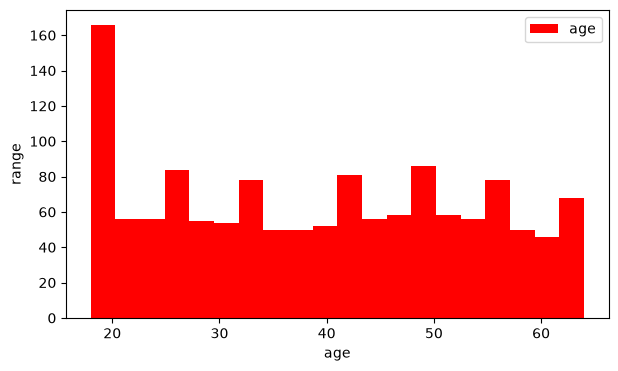

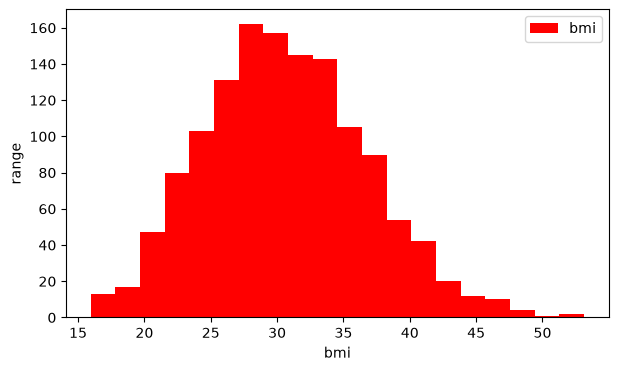

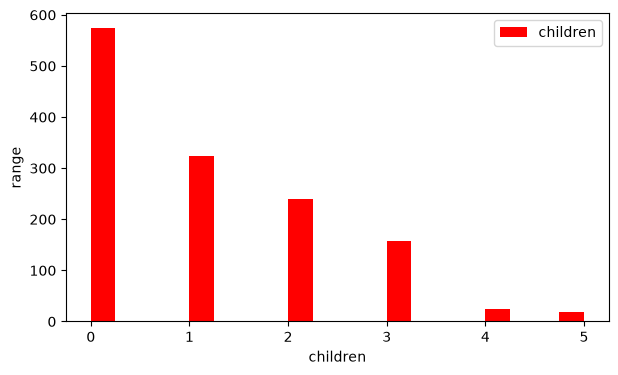

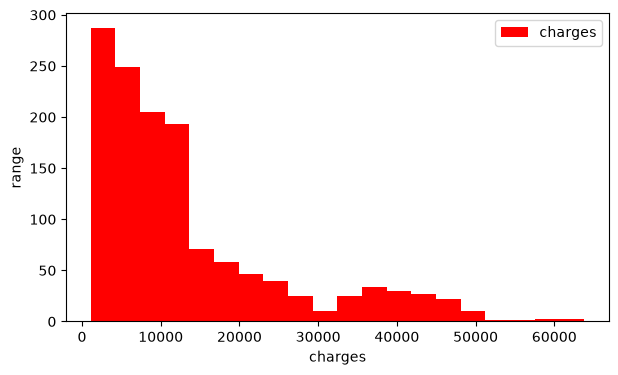

In [8]:
# now getting numeric colums for ploting them
numeric_colums = ["age" , "bmi" , "children" , "charges"]
for col in numeric_colums:
    mlt.figure(figsize=(7,4));
    mlt.hist(df[col],bins=20 , label=(col) , color="red");
    mlt.xlabel(col)
    mlt.ylabel("range")
    mlt.legend();
    mlt.show()

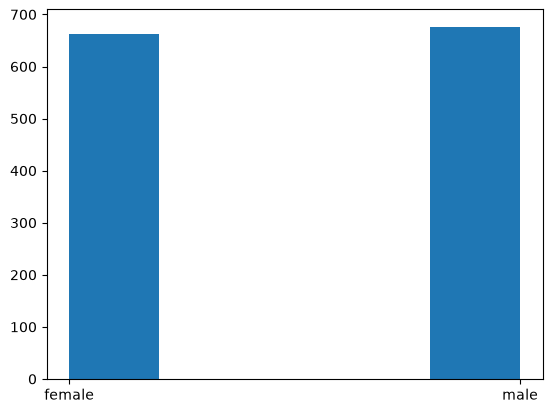

In [9]:
mlt.hist(df["sex"],bins=5)
mlt.show()

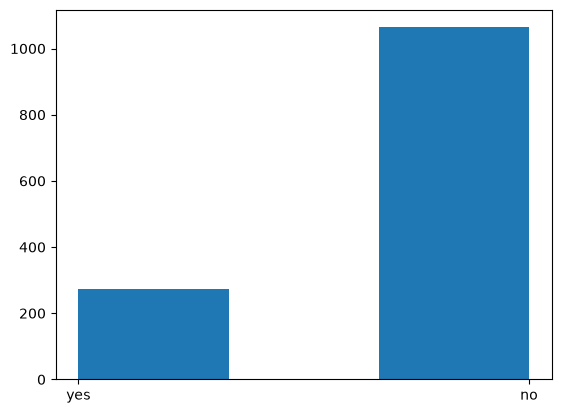

In [10]:
mlt.hist(df["smoker"],bins=3)
mlt.show()

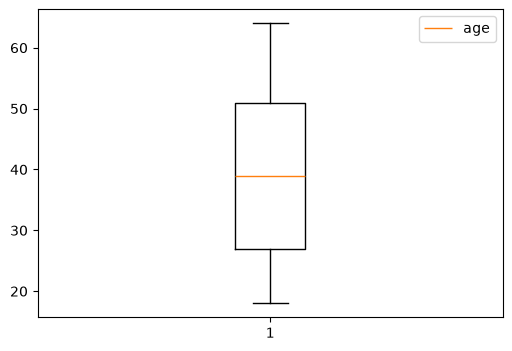

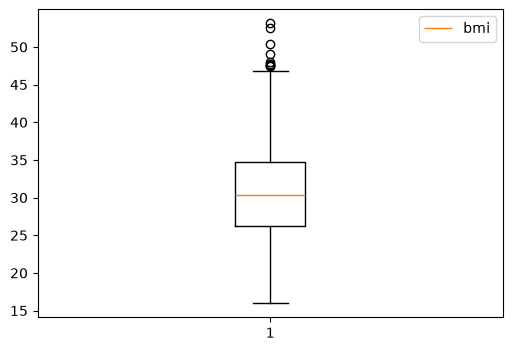

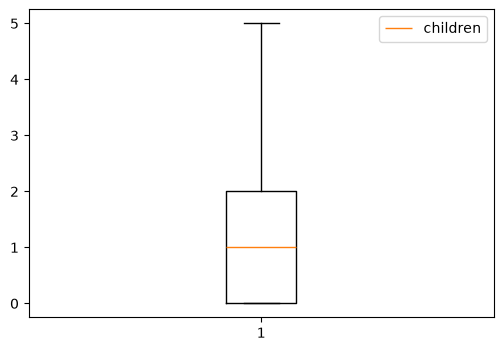

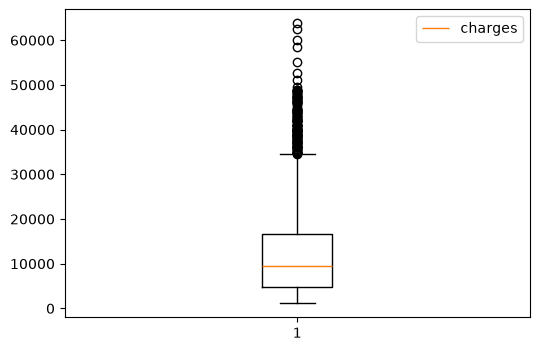

In [11]:
for col in numeric_colums:
    mlt.figure(figsize=(6,4))
    mlt.boxplot(x = df[col] , label=(col))
    mlt.legend()
    mlt.show()

# Data Cleaning And Preprossing

In [12]:
df.isnull().sum() # result : it mean there is no null values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [13]:
df["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [14]:
df.shape

(1338, 7)

In [15]:
df.drop_duplicates(inplace=True) # duplicate removed

In [16]:
df.shape

(1337, 7)

In [17]:
# now convert the str into integer 
df["sex"] = df["sex"].map({"male" : 0 , "female" : 1})
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [18]:
df["smoker"] = df["smoker"].map({"yes" : 1 , "no" : 0})

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [19]:
df["smoker"].value_counts() 
# here is also only yes and no , and there no extra value to drop

smoker
0    1063
1     274
Name: count, dtype: int64

In [20]:
# now changing the names of columns
df.rename(columns={"sex" : "is_femail" , "smoker" : "is_smoker"} , inplace=True);
df.head()

,age,is_femail,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [21]:
df["region"].value_counts() 
# value_count tells us that how many diffrent values are there

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [22]:
df= pd.get_dummies(df , columns=["region"])
df.head()

,age,is_femail,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [23]:
df.isnull().sum()
# df = df.astype(int)
df.head()

,age,is_femail,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


# Feature Engineering and Extraction 

In [24]:
df.head()

,age,is_femail,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


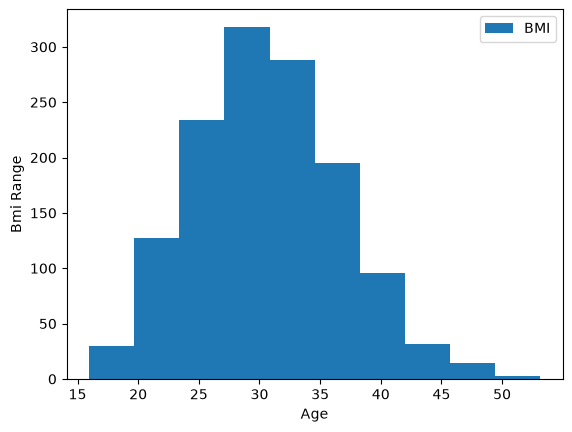

In [25]:
mlt.hist(df["bmi"] , label=("BMI"))
mlt.legend()
mlt.xlabel("Age")
mlt.ylabel("Bmi Range")
mlt.show()

here i am extracting bmi feature 

In [26]:
df["clean_bmi"] = pd.cut(
    df['bmi'], 
    bins=[ 0,18.5,24,30,float("inf") ] , 
    labels=["underweight" , "normal" , "overweight", "obese"]
)
df.head()

,age,is_femail,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,clean_bmi
0,19,1,27.900,0,1,16884.92400,False,False,False,True,overweight
1,18,0,33.770,1,0,1725.55230,False,False,True,False,obese
2,28,0,33.000,3,0,4449.46200,False,False,True,False,obese
3,33,0,22.705,0,0,21984.47061,False,True,False,False,normal
4,32,0,28.880,0,0,3866.85520,False,True,False,False,overweight


In [27]:
df = pd.get_dummies(df , columns=["clean_bmi"] , dtype=bool)

In [28]:
df.head()

,age,is_femail,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,clean_bmi_underweight,clean_bmi_normal,clean_bmi_overweight,clean_bmi_obese
0,19,1,27.900,0,1,16884.92400,False,False,False,True,False,False,True,False
1,18,0,33.770,1,0,1725.55230,False,False,True,False,False,False,False,True
2,28,0,33.000,3,0,4449.46200,False,False,True,False,False,False,False,True
3,33,0,22.705,0,0,21984.47061,False,True,False,False,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False,False,False,True,False


In [29]:
convert = {
    "region_northeast": int ,
    "region_northwest" : int ,
    "region_southeast" : int ,
    "region_southwest" : int ,
    "clean_bmi_underweight" : int ,
    "clean_bmi_normal" : int ,
    "clean_bmi_overweight" : int ,
    "clean_bmi_obese" : int ,
}

df = df.astype(convert)

In [30]:
df.head()

,age,is_femail,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,clean_bmi_underweight,clean_bmi_normal,clean_bmi_overweight,clean_bmi_obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,0,0,1,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,0,1,0,0,0,0,1
3,33,0,22.705,0,0,21984.47061,0,1,0,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,0,1,0


In [31]:
df = df.drop(columns=['bmi'])
df.head()

,age,is_femail,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,clean_bmi_underweight,clean_bmi_normal,clean_bmi_overweight,clean_bmi_obese
0,19,1,0,1,16884.92400,0,0,0,1,0,0,1,0
1,18,0,1,0,1725.55230,0,0,1,0,0,0,0,1
2,28,0,3,0,4449.46200,0,0,1,0,0,0,0,1
3,33,0,0,0,21984.47061,0,1,0,0,0,1,0,0
4,32,0,0,0,3866.85520,0,1,0,0,0,0,1,0


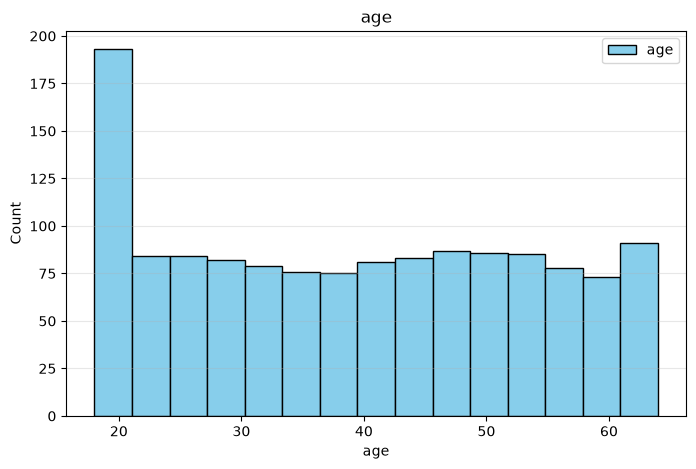

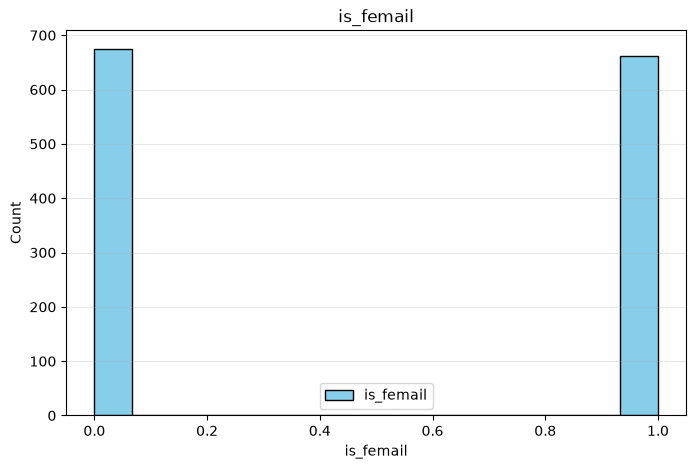

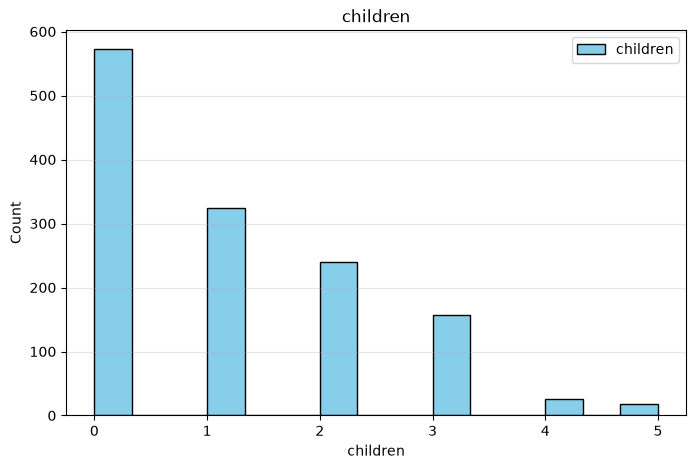

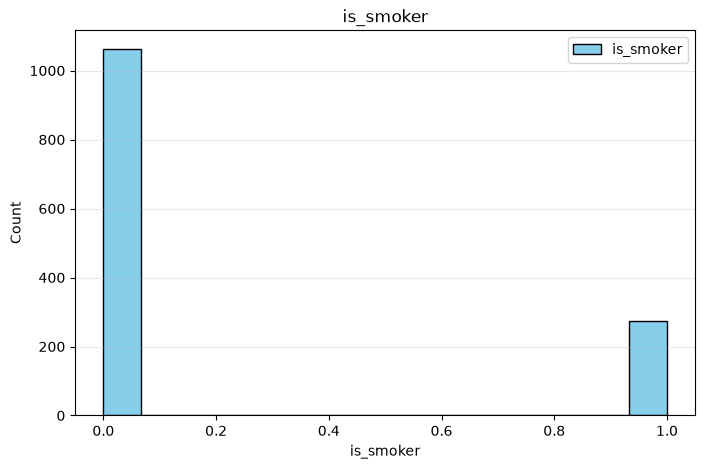

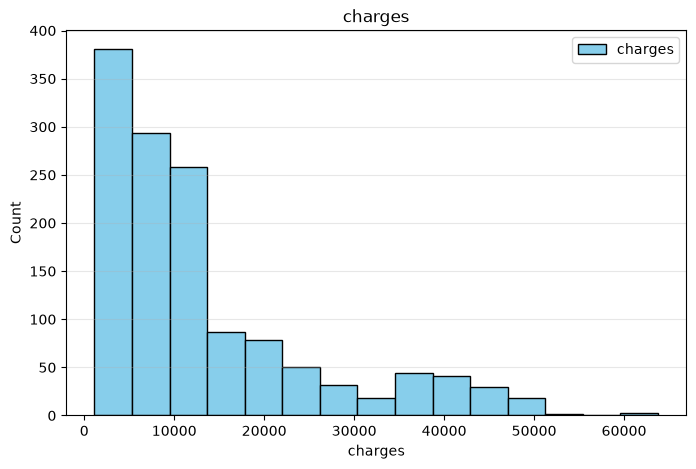

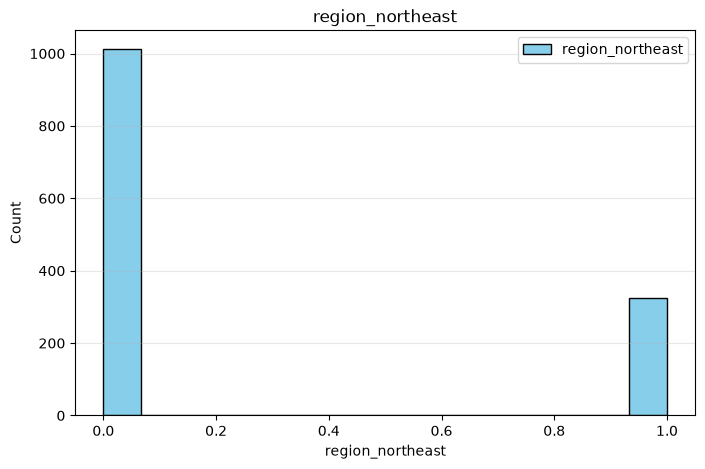

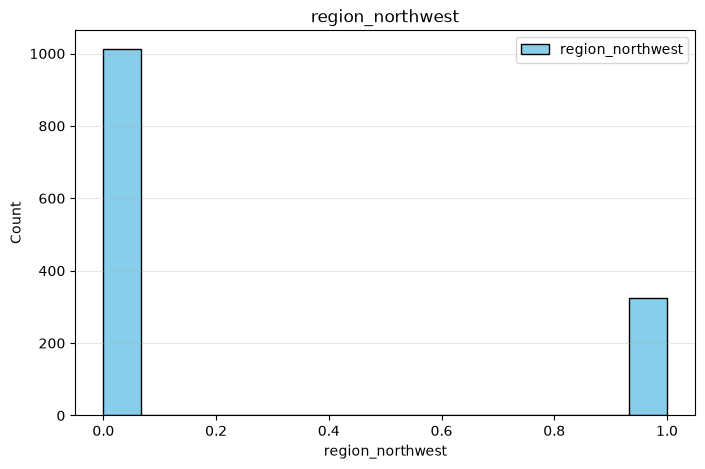

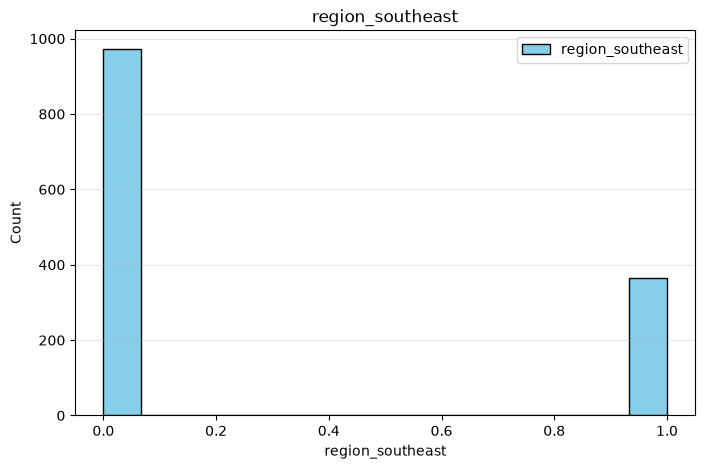

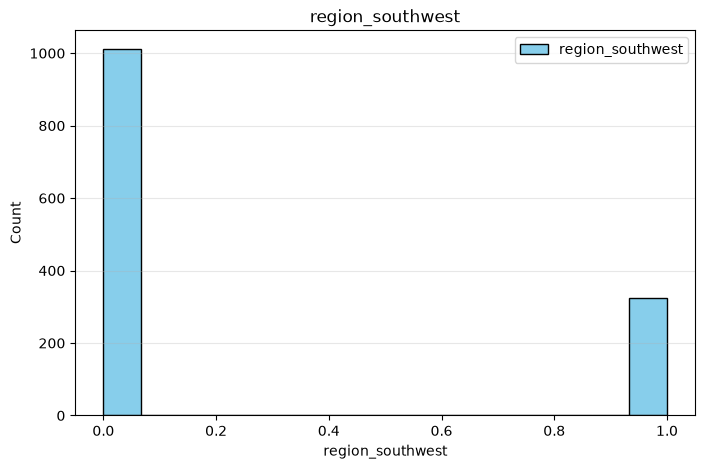

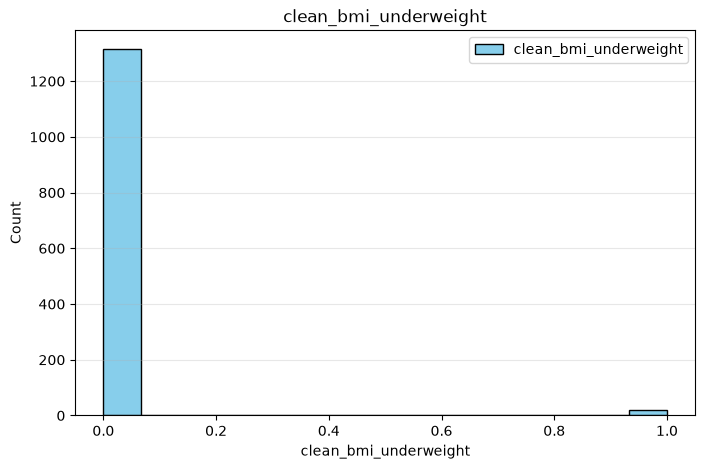

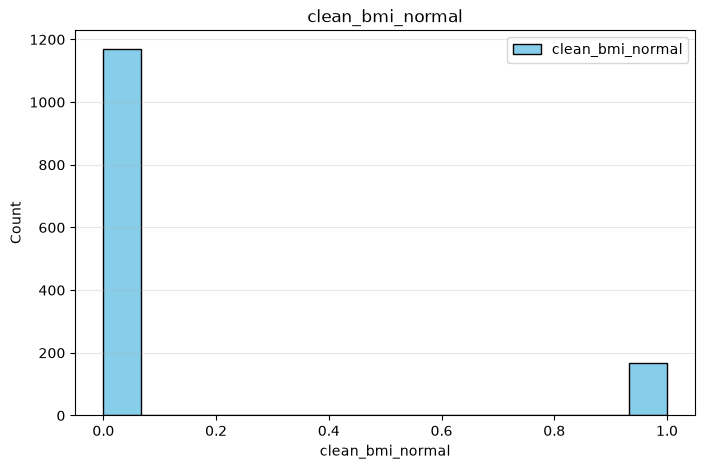

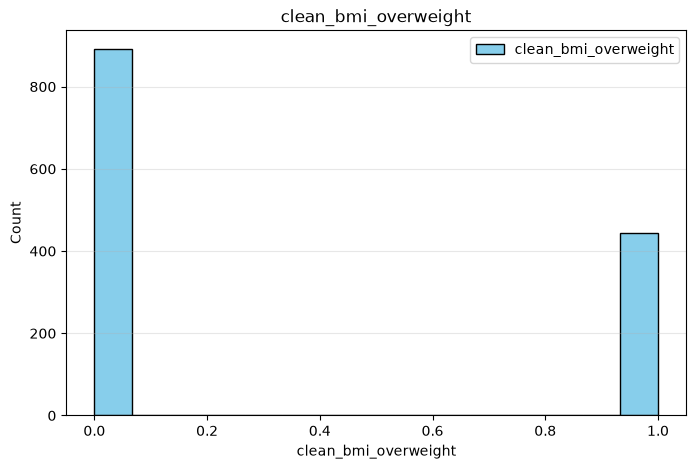

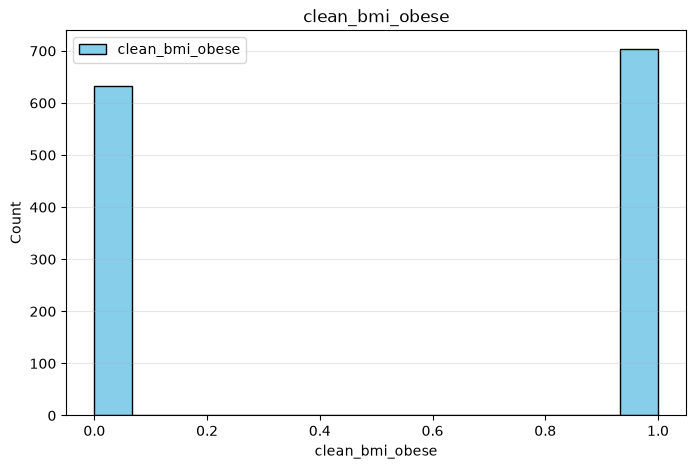

In [32]:
for col in df.columns:
    mlt.figure(figsize=(8, 5))
    
    mlt.hist(df[col], bins=15, edgecolor='black', label=col, color='skyblue')
    
    mlt.title(col)
    mlt.xlabel(col)
    mlt.ylabel("Count")
    mlt.legend()
    mlt.grid(axis='y', alpha=0.3)  # adds scannable gridlines
    
    mlt.show()


In [33]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


Feature Scalling : 

In [34]:
df.head()

,age,is_femail,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,clean_bmi_underweight,clean_bmi_normal,clean_bmi_overweight,clean_bmi_obese
0,19,1,0,1,16884.92400,0,0,0,1,0,0,1,0
1,18,0,1,0,1725.55230,0,0,1,0,0,0,0,1
2,28,0,3,0,4449.46200,0,0,1,0,0,0,0,1
3,33,0,0,0,21984.47061,0,1,0,0,0,1,0,0
4,32,0,0,0,3866.85520,0,1,0,0,0,0,1,0


In [35]:
df = df.dropna(subset=['is_smoker'])

if df['is_smoker'].dtype == object:
    df['is_smoker'] = df['is_smoker'].map({'yes': 1, 'no': 0})
df['is_smoker'] = df['is_smoker'].astype(int)

df.head()

,age,is_femail,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,clean_bmi_underweight,clean_bmi_normal,clean_bmi_overweight,clean_bmi_obese
0,19,1,0,1,16884.92400,0,0,0,1,0,0,1,0
1,18,0,1,0,1725.55230,0,0,1,0,0,0,0,1
2,28,0,3,0,4449.46200,0,0,1,0,0,0,0,1
3,33,0,0,0,21984.47061,0,1,0,0,0,1,0,0
4,32,0,0,0,3866.85520,0,1,0,0,0,0,1,0


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
colums = ["age" , "children"]
df[colums] = scaler.fit_transform(df[colums])
df.head()

,age,is_femail,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,clean_bmi_underweight,clean_bmi_normal,clean_bmi_overweight,clean_bmi_obese
0,-1.440418,1,-0.909234,1,16884.92400,0,0,0,1,0,0,1,0
1,-1.511647,0,-0.079442,0,1725.55230,0,0,1,0,0,0,0,1
2,-0.799350,0,1.580143,0,4449.46200,0,0,1,0,0,0,0,1
3,-0.443201,0,-0.909234,0,21984.47061,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.909234,0,3866.85520,0,1,0,0,0,0,1,0


In [37]:
df.columns

Index(['age', 'is_femail', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'clean_bmi_underweight', 'clean_bmi_normal',
       'clean_bmi_overweight', 'clean_bmi_obese'],
      dtype='str')

### Feature Selection : 
specifically, checking which features are worth keeping by measuring how strongly each one relates to your target (charges).

In [38]:
# Feature Selection Method 1 : 

from sklearn.feature_selection import f_classif , SelectKBest

output_feature = df["charges"] # this is the column you want to predict - output feature
columns = ['age', 'is_femail', 'children', 'is_smoker',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'clean_bmi_underweight', 'clean_bmi_normal',
       'clean_bmi_overweight', 'clean_bmi_obese']

targeted_columns = df[columns] 
# holds only the specific columns you want to test

selector = SelectKBest(score_func=f_classif , k=1) 
# Configure the selector 'k=2' means you want the computer to pick the top 2 best columns 
# from your list

run_selector = selector.fit_transform(targeted_columns , output_feature);
# Running Selector -- This scores the columns and filters them down to the top 2


selected_state = selector.get_support()
# See which columns won This shows True for the columns kept, and False for the ones dropped


print(dict(zip(targeted_columns , selected_state)))


{'age': np.False_, 'is_femail': np.False_, 'children': np.False_, 'is_smoker': np.False_, 'region_northeast': np.False_, 'region_northwest': np.False_, 'region_southeast': np.False_, 'region_southwest': np.False_, 'clean_bmi_underweight': np.False_, 'clean_bmi_normal': np.False_, 'clean_bmi_overweight': np.False_, 'clean_bmi_obese': np.True_}


In [39]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [40]:
# Feature Selection Method 2 : 

from scipy.stats import pearsonr

targeted_Feature = df["charges"] 
# this is the column you want to predict - output feature

extract_columns = ['age', 'is_femail', 'children', 'is_smoker',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'clean_bmi_underweight', 'clean_bmi_normal',
       'clean_bmi_overweight', 'clean_bmi_obese']

test_columns = df[extract_columns] 
# holds only the specific columns you want to test

correlation = {
    feature: pearsonr(test_columns[feature], targeted_Feature)[0]
    for feature in extract_columns
}

# Looping through each feature column one by one, and calculating its Pearson correlation
# with the target column (targeted_Feature / charges).
# pearsonr() returns two values: (correlation_value, p_value) -> we only keep [0], the correlation_value.
# Result: a dictionary where each feature name is mapped to how strongly it's linearly related to charges.

correlation_df = pd.DataFrame(list(correlation.items()), columns=['Feature', 'Pearson Correlation'])
# here we create a data frame of correlation items that contain two columsn of feature and correlation

correlation_df.sort_values(by='Pearson Correlation', ascending=False)
# here sort them by deceding order 

,Feature,Pearson Correlation
3,is_smoker,0.787234
0,age,0.298308
11,clean_bmi_obese,0.200501
6,region_southeast,0.073578
2,children,0.067389
4,region_northeast,0.005945
5,region_northwest,-0.038695
7,region_southwest,-0.043637
8,clean_bmi_underweight,-0.048225
1,is_femail,-0.058044


In [41]:
from scipy.stats import chi2_contingency
# Importing the statistical test function.
import pandas as pd

alpha = 0.05
# it means : How much risk of being wrong am I okay with?

df["charges_bins"] = pd.qcut(df["charges"] , q=4 , labels=False);
# creating quality bins of equal sizes of charges thorugh pandas 
# q=4 → 4 groups (quartiles)

chi2_result = {} # here we will store chi2_contingency result

cat_features = ['age', 'is_femail', 'children', 'is_smoker',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'clean_bmi_underweight', 'clean_bmi_normal',
       'clean_bmi_overweight', 'clean_bmi_obese']

for col in cat_features:
       contingency = pd.crosstab(df[col] , df["charges_bins"])
       chi2_state , p_value , _ , _ = chi2_contingency(contingency);
       if p_value < alpha:
              decision = "Keep Feature"
       else:
              decision = "Drop Feature"
       chi2_result[col] = {
              "Chi_2_Statistics" : chi2_state ,
              "p_value" : p_value ,
              "Decision" : decision
       }
       
chi2_df = pd.DataFrame(chi2_result).T
chi2_df = chi2_df.sort_values(by="p_value")
chi2_df

,Chi_2_Statistics,p_value,Decision
age,1509.13025,0.0,Keep Feature
is_smoker,848.219178,0.0,Keep Feature
children,138.659313,0.0,Keep Feature
region_southeast,15.998167,0.001135,Keep Feature
is_femail,10.258784,0.01649,Keep Feature
clean_bmi_obese,8.554126,0.035846,Keep Feature
clean_bmi_normal,8.142374,0.043159,Keep Feature
region_northeast,6.438442,0.092122,Drop Feature
region_southwest,5.091893,0.165191,Drop Feature
clean_bmi_underweight,4.384749,0.222804,Drop Feature


In [44]:
final_df = df[[
    "age",
    "is_smoker",
    "children",
    "region_southeast",
    "is_femail",
    "clean_bmi_obese",
    "clean_bmi_normal"
]]

final_df.head()

,age,is_smoker,children,region_southeast,is_femail,clean_bmi_obese,clean_bmi_normal
0,-1.440418,1,-0.909234,0,1,0,0
1,-1.511647,0,-0.079442,1,0,1,0
2,-0.799350,0,1.580143,1,0,1,0
3,-0.443201,0,-0.909234,0,0,0,1
4,-0.514431,0,-0.909234,0,0,0,0
